In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

In [2]:
manifest_path = Path("../artifacts/data_audit/hdfs_v1_audit.json")
manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
manifest["acceptance"]

{'accepted': True,
 'checks': {'all_labels_have_event': True,
  'all_log_bytes_decode_as_utf8': True,
  'all_log_headers_parse': True,
  'all_observed_block_ids_have_label': True,
  'expected_anomaly_labels': True,
  'expected_labels_sha256': True,
  'expected_log_line_count': True,
  'expected_log_sha256': True,
  'expected_normal_labels': True,
  'expected_unique_labels': True,
  'log_line_accounting_closes': True,
  'no_blank_label_values': True,
  'no_conflicting_labels': True,
  'no_duplicate_label_rows': True,
  'no_invalid_label_block_ids': True,
  'no_invalid_label_domain': True,
  'parsed_line_session_accounting_closes': True}}

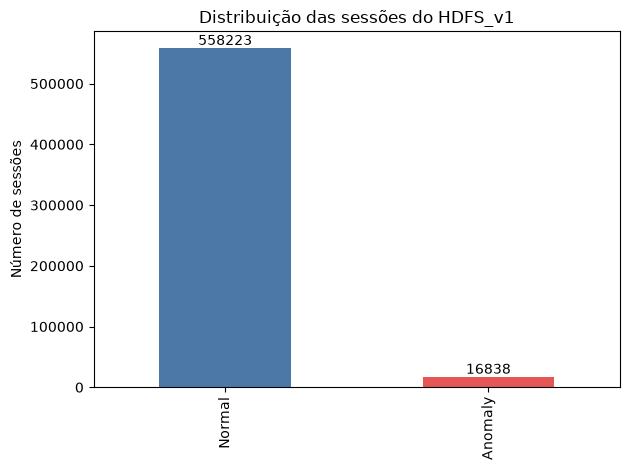

In [4]:
label_counts = pd.Series(
    {
        "Normal": manifest["labels"]["normal"],
        "Anomaly": manifest["labels"]["anomaly"],
    }
)

axis = label_counts.plot.bar(
    title="Distribuição das sessões do HDFS_v1",
    ylabel="Número de sessões",
    color=["#4C78A8", "#E45756"],
)

axis.bar_label(axis.containers[0])
plt.tight_layout()